In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
data_dir = Path("./CSV_Files")
csv_files = sorted(data_dir.glob("*.csv"))
print(csv_files)


In [73]:
import re
pieces = []
for f in csv_files:
    df = pd.read_csv(f,usecols=["value"])
    df = df.rename(columns={"value":"strain_levels"})
    df["filename"] = f.name
    match = re.search(r"plot_data_(\d+)",f.stem)
    df["run_number"] = int(match.group(1))
    pieces.append(df)

Data = pd.concat(pieces, ignore_index=True)

In [74]:
run_to_load = {
    1: 2.26,
    2: 5.56,
    3: 9.89,
    4: 20.0,
    5: 30.0,
    6: 40.0,
    7: 50.0,
    8: 60.0,
    9: 70.0,
    10: 80.0,
    11: 90.0,
    12: 100.0,
    13: 110.0,
    14: 120.0,
    15: 130.0,
    16: 140.0,
    17: 150.0
}

Data["load_gram"] = Data["run_number"].map(run_to_load)
Data["load_newton"] = Data["load_gram"] * 9.81 / 1000
Data["load_millNewton"] = Data["load_newton"] * 1000




LinregressResult(slope=np.float64(0.0835503712082693), intercept=np.float64(31.95833135765122), rvalue=np.float64(0.9999132289025299), pvalue=np.float64(0.0), stderr=np.float64(2.586266107263828e-06), intercept_stderr=np.float64(0.028711536673645954))


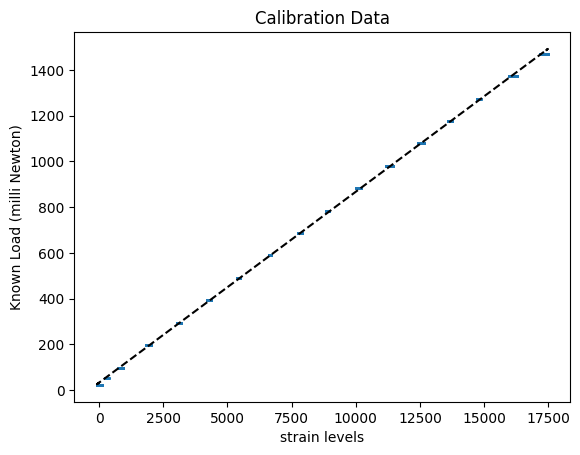

In [75]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
plt.figure()
plt.scatter(Data["strain_levels"].values,Data["load_millNewton"].values,s=.5)
plt.xlabel("strain levels")
plt.ylabel("Known Load (milli Newton)")
plt.title("Calibration Data")



linregress_results = linregress(Data["strain_levels"],Data["load_millNewton"])
print(linregress_results)
#
M = linregress_results.slope
b = linregress_results.intercept
predicted_load = M*Data["strain_levels"] + b
plt.plot(Data["strain_levels"],predicted_load,'k--',label='Predicted Load')

plt.show()

In [76]:
summary = pd.Series(linregress_results._asdict())
summary["r_squared"] = summary["rvalue"]**2 
summary

slope                0.083550
intercept           31.958331
rvalue               0.999913
pvalue               0.000000
stderr               0.000003
intercept_stderr     0.028712
r_squared            0.999826
dtype: float64

In [77]:
summary_df = pd.DataFrame([linregress_results._asdict()])
summary_df["r_squared"] = summary_df["rvalue"]**2
summary_df

,slope,intercept,rvalue,pvalue,stderr,intercept_stderr,r_squared
0,0.08355,31.958331,0.999913,0.0,0.000003,0.028712,0.999826


In [ ]:
# Negated relative to the raw fit (M, b above) so positive output means
# "load to the left," matching the sign convention already used in the ROS
# firmware calibration (ForceCalibratorNode.py) - not a different
# calibration, just the oriented version of the same one.
Data["force_milliNewton"] = -M * Data["strain_levels"] - b
Data[["strain_levels", "force_milliNewton"]].head()